# Manning's n from NLCD Validation

Validate `ManningsFromLandCover` on the real `BaldEagleCrkMulti2D` RasExamples project. The workflow compares the existing 1D geometry Manning's n blocks against automated NLCD-derived horizontal variation, checks the project RAS Mapper land-cover sidecar values, and quantifies where the 20-block HEC-RAS limit forces block merging.


## Validation Design

This notebook uses `BaldEagleCrkMulti2D` geometry `g06` because it has real 1D cross-section cut lines and a registered RAS Mapper land-cover layer (`Land Classification/LandCover.hdf` with matching GeoTIFF). The original extracted project geometry is left unchanged; `ManningsFromLandCover.assign()` writes to a copied geometry in the notebook output folder.

The comparison has three references:

| Reference | Purpose |
|---|---|
| Existing geometry `#Mann` blocks | Baseline 1D roughness currently in the model |
| RAS Mapper sidecar `Variables/ManningsN` table | Project land-cover class-to-n reference |
| Raw unmerged NLCD preview | Hydraulic-character reference before the 20-block limit is enforced |


In [1]:
from pathlib import Path
import logging
import os
import shutil

os.environ.setdefault("NUMEXPR_MAX_THREADS", "8")

import geopandas as gpd
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import StrMethodFormatter
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import from_bounds

from ras_commander import RasExamples, RasMap, init_ras_project, ras
from ras_commander.geom import GeomCrossSection, GeomParser, ManningsFromLandCover
from ras_commander.hdf import HdfLandCover

for logger_name in [
    "",
    "rasterio",
    "fiona",
    "pyogrio",
    "ras_commander",
    "ras_commander.RasExamples",
    "ras_commander.RasMap",
    "ras_commander.RasPrj",
    "ras_commander.RasUtils",
    "ras_commander.geom.GeomParser",
    "ras_commander.geom.ManningsFromLandCover",
    "ras_commander.hdf.HdfLandCover",
]:
    logging.getLogger(logger_name).setLevel(logging.ERROR)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 180,
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

pd.set_option("display.max_columns", 24)
pd.set_option("display.width", 160)

REPO_ROOT = Path.cwd().resolve()
OUTPUT_DIR = REPO_ROOT / "working" / "CLB-665" / "notebook_outputs"
PROJECT_OUTPUT_DIR = OUTPUT_DIR / "projects"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PROJECT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RAS_VERSION = "7.0"
GEOMETRY_NUMBER = "06"
MAX_MANNING_BLOCKS = ManningsFromLandCover.DEFAULT_MAX_BLOCKS


def rel(path: Path | str) -> str:
    path = Path(path).resolve()
    try:
        return str(path.relative_to(REPO_ROOT))
    except ValueError:
        return path.name


def xs_sort_key(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce").fillna(-np.inf)


## Extract the Real Example Project

The project extraction is reproducible and writes to the ignored working folder. Geometry `g06` is the largest 1D/2D Bald Eagle geometry with 192 cross sections that have GIS cut lines and a registered land-cover raster covering the model.


In [2]:
project_path = Path(
    RasExamples.extract_project(
        "BaldEagleCrkMulti2D",
        output_path=PROJECT_OUTPUT_DIR,
        suffix="clb665_nlcd_validation",
    )
).resolve()
init_ras_project(project_path, RAS_VERSION)

geom_row = ras.geom_df.loc[
    ras.geom_df["geom_number"].astype(str).str.zfill(2) == GEOMETRY_NUMBER
].iloc[0]
geometry_path = Path(geom_row["full_path"]).resolve()

landcover_layers = RasMap.list_landcover_layers(project_path)
mapper_layer = landcover_layers.loc[
    landcover_layers["selected_parameter"].astype(str).str.casefold() == "manningsn"
].iloc[0]
landcover_hdf = Path(mapper_layer["resolved_path"]).resolve()
landcover_tif = landcover_hdf.with_suffix(".tif")

# Copy the raster to an analysis filename without a matching .hdf sidecar so
# preview/assign use the explicit RAS Mapper class table below without trying
# to load optional classification polygons.
analysis_raster = OUTPUT_DIR / "LandCover_CLB665_analysis.tif"
shutil.copy2(landcover_tif, analysis_raster)

raster_map = HdfLandCover.get_landcover_raster_map(landcover_hdf)
mapper_mannings_table = raster_map.rename(
    columns={
        "pixel_value": "pixel_value",
        "class_name": "class_name",
        "mannings_n": "mannings_n",
    }
)[["pixel_value", "class_name", "mannings_n"]].copy()
mapper_lookup = {
    int(row["pixel_value"]): {
        "class_name": str(row["class_name"]),
        "mannings_n": float(row["mannings_n"]),
    }
    for _, row in mapper_mannings_table.iterrows()
}

cut_lines = GeomParser.get_xs_cut_lines(geometry_path)
cross_sections = GeomCrossSection.get_cross_sections(geometry_path)
xs_rows = cross_sections.merge(
    cut_lines.rename(columns={"river": "River", "reach": "Reach", "station": "RS"}),
    on=["River", "Reach", "RS"],
    how="inner",
)
xs_rows = xs_rows.sort_values("RS", key=xs_sort_key, ascending=False).reset_index(drop=True)

project_summary = pd.DataFrame(
    [
        {"item": "RasExamples project", "value": project_path.name},
        {"item": "geometry", "value": geometry_path.name},
        {"item": "geometry title", "value": geom_row.get("geom_title", "")},
        {"item": "XS with GIS cut lines", "value": len(xs_rows)},
        {"item": "RAS Mapper land-cover layer", "value": mapper_layer["name"]},
        {"item": "analysis raster", "value": rel(analysis_raster)},
        {"item": "Manning block limit", "value": MAX_MANNING_BLOCKS},
    ]
)
display(project_summary)
display(mapper_mannings_table.head(12))

assert len(xs_rows) == 192
assert analysis_raster.exists()


,item,value
0,RasExamples project,BaldEagleCrkMulti2D_clb665_nlcd_validation
1,geometry,BaldEagleDamBrk.g06
2,geometry title,Bald Eagle Multi 2D Areas
3,XS with GIS cut lines,192
4,RAS Mapper land-cover layer,LandCover
5,analysis raster,working\CLB-665\notebook_outputs\LandCover_CLB...
6,Manning block limit,20


,pixel_value,class_name,mannings_n
0,0,NoData,0.035
1,43,Mixed Forest,0.120
2,41,Deciduous Forest,0.100
3,21,"Developed, Open Space",0.035
4,42,Evergreen Forest,0.150
5,11,Open Water,0.035
6,52,Shrub-Scrub,0.050
7,81,Pasture-Hay,0.045
8,71,Grassland-Herbaceous,0.040
9,82,Cultivated Crops,0.050


## Existing Geometry Baseline

The existing geometry uses the standard three-block LOB/channel/ROB Manning's n pattern. This baseline is the reference for station-by-station discrepancy plots after the NLCD assignment is generated.


In [3]:
def collect_mannings(geom_path: Path, xs_index: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, xs in xs_index.iterrows():
        mann = GeomCrossSection.get_mannings_n(
            geom_path,
            str(xs["River"]),
            str(xs["Reach"]),
            str(xs["RS"]),
        )
        if mann.empty:
            continue
        mann = mann.copy()
        mann["River"] = str(xs["River"])
        mann["Reach"] = str(xs["Reach"])
        mann["RS"] = str(xs["RS"])
        rows.append(mann)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


baseline_mannings = collect_mannings(geometry_path, xs_rows)
baseline_counts = (
    baseline_mannings.groupby(["River", "Reach", "RS"], as_index=False)
    .size()
    .rename(columns={"size": "baseline_block_count"})
)

baseline_summary = baseline_counts["baseline_block_count"].describe().to_frame("baseline blocks")
baseline_values = (
    baseline_mannings.groupby(["Subsection", "n_value"], as_index=False)
    .size()
    .sort_values(["Subsection", "n_value"])
)
display(baseline_summary)
display(baseline_values)
display(baseline_mannings.head(9))

assert baseline_counts["baseline_block_count"].eq(3).all()


,baseline blocks
count,192.0
mean,3.0
std,0.0
min,3.0
25%,3.0
50%,3.0
75%,3.0
max,3.0


,Subsection,n_value,size
0,Channel,0.040,171
1,Channel,0.045,3
2,Channel,0.050,3
3,Channel,0.055,3
4,Channel,0.060,3
5,Channel,0.065,3
6,Channel,0.075,3
7,Channel,0.080,4
8,LOB,0.050,6
9,LOB,0.060,138


,Station,n_value,Subsection,River,Reach,RS
0,0.00,0.06,LOB,Bald Eagle Cr.,Lock Haven,137520
1,3149.24,0.04,Channel,Bald Eagle Cr.,Lock Haven,137520
2,3627.56,0.08,ROB,Bald Eagle Cr.,Lock Haven,137520
3,0.00,0.06,LOB,Bald Eagle Cr.,Lock Haven,136948
4,3130.11,0.04,Channel,Bald Eagle Cr.,Lock Haven,136948
5,3496.33,0.08,ROB,Bald Eagle Cr.,Lock Haven,136948
6,0.00,0.06,LOB,Bald Eagle Cr.,Lock Haven,136076
7,2600.34,0.04,Channel,Bald Eagle Cr.,Lock Haven,136076
8,3031.99,0.08,ROB,Bald Eagle Cr.,Lock Haven,136076


## Raw NLCD Preview and Assigned Geometry

First, `preview(..., max_blocks=999)` captures the raw land-cover segmentation without enforcing the HEC-RAS block limit. Then `assign(..., max_blocks=20)` writes a copied geometry using the same source geometry and analysis raster.


In [4]:
raw_preview = ManningsFromLandCover.preview(
    geometry_path,
    analysis_raster,
    mannings_table=mapper_mannings_table,
    max_blocks=999,
)

assigned_geometry_path = OUTPUT_DIR / f"{geometry_path.stem}_nlcd_assigned{geometry_path.suffix}"
shutil.copy2(geometry_path, assigned_geometry_path)
assignment_result = ManningsFromLandCover.assign(
    assigned_geometry_path,
    analysis_raster,
    mannings_table=mapper_mannings_table,
    max_blocks=MAX_MANNING_BLOCKS,
)
automated_preview = assignment_result["details"].copy()
assigned_mannings = collect_mannings(assigned_geometry_path, xs_rows)

raw_counts = (
    raw_preview.groupby(["River", "Reach", "RS"], as_index=False)
    .agg(raw_block_count=("n_value", "size"))
)
automated_counts = (
    automated_preview.groupby(["River", "Reach", "RS"], as_index=False)
    .agg(
        automated_block_count=("n_value", "size"),
        reported_raw_block_count=("raw_block_count", "max"),
        merged_rows=("merged_count", lambda values: int((values.astype(int) > 1).sum())),
        n_min=("n_value", "min"),
        n_max=("n_value", "max"),
    )
)
assigned_counts = (
    assigned_mannings.groupby(["River", "Reach", "RS"], as_index=False)
    .size()
    .rename(columns={"size": "assigned_block_count"})
)

block_counts = (
    baseline_counts.merge(raw_counts, on=["River", "Reach", "RS"], how="inner")
    .merge(automated_counts, on=["River", "Reach", "RS"], how="inner")
    .merge(assigned_counts, on=["River", "Reach", "RS"], how="inner")
)
block_counts["merge_triggered"] = block_counts["raw_block_count"] > block_counts["automated_block_count"]
block_counts["block_reduction"] = block_counts["raw_block_count"] - block_counts["automated_block_count"]
block_counts = block_counts.sort_values(
    ["merge_triggered", "raw_block_count", "RS"],
    ascending=[False, False, False],
).reset_index(drop=True)

block_counts_path = OUTPUT_DIR / "clb665_block_counts.csv"
block_counts.to_csv(block_counts_path, index=False)

assignment_summary = pd.DataFrame(
    [
        {"metric": "total XS in geometry", "value": assignment_result["cross_sections_total"]},
        {"metric": "XS processed from land cover", "value": assignment_result["cross_sections_processed"]},
        {"metric": "XS skipped without cut-line coverage", "value": assignment_result["cross_sections_skipped"]},
        {"metric": "Manning blocks written", "value": assignment_result["blocks_written"]},
        {"metric": "XS where merging triggered", "value": int(block_counts["merge_triggered"].sum())},
        {"metric": "maximum raw block count", "value": int(block_counts["raw_block_count"].max())},
        {"metric": "maximum assigned block count", "value": int(block_counts["assigned_block_count"].max())},
        {"metric": "block count CSV", "value": rel(block_counts_path)},
    ]
)
display(assignment_summary)
display(block_counts.head(15))

assert assignment_result["cross_sections_processed"] == len(xs_rows)
assert block_counts["assigned_block_count"].max() <= MAX_MANNING_BLOCKS
assert block_counts["merge_triggered"].any()


,metric,value
0,total XS in geometry,212
1,XS processed from land cover,192
2,XS skipped without cut-line coverage,20
3,Manning blocks written,3414
4,XS where merging triggered,115
5,maximum raw block count,66
6,maximum assigned block count,20
7,block count CSV,working\CLB-665\notebook_outputs\clb665_block_...


,River,Reach,RS,baseline_block_count,raw_block_count,automated_block_count,reported_raw_block_count,merged_rows,n_min,n_max,assigned_block_count,merge_triggered,block_reduction
0,Bald Eagle Cr.,Lock Haven,36694,3,66,20,66,2,0.035,0.12,20,True,46
1,Bald Eagle Cr.,Lock Haven,33911,3,64,20,64,2,0.035,0.12,20,True,44
2,Bald Eagle Cr.,Lock Haven,35393,3,61,20,61,2,0.035,0.15,20,True,41
3,Bald Eagle Cr.,Lock Haven,31780,3,60,20,60,2,0.035,0.15,20,True,40
4,Bald Eagle Cr.,Lock Haven,41358,3,58,20,58,2,0.035,0.12,20,True,38
5,Bald Eagle Cr.,Lock Haven,32863,3,58,20,58,2,0.035,0.12,20,True,38
6,Bald Eagle Cr.,Lock Haven,39335,3,57,20,57,2,0.035,0.12,20,True,37
7,Bald Eagle Cr.,Lock Haven,26692,3,55,20,55,2,0.035,0.12,20,True,35
8,Bald Eagle Cr.,Lock Haven,36808,3,54,20,54,2,0.035,0.12,20,True,34
9,Bald Eagle Cr.,Lock Haven,69539,3,51,20,51,1,0.035,0.12,20,True,31


## Agreement Metrics and Largest Station Differences

The station comparison evaluates each assigned Manning breakpoint against the pre-existing geometry value active at that same station. The RAS Mapper sidecar check verifies that raw sampled NLCD blocks use the project sidecar's `ManningsN` values.


In [5]:
def reference_n_at_stations(reference_df: pd.DataFrame, station_values: pd.Series) -> np.ndarray:
    reference_df = reference_df.sort_values("Station")
    starts = reference_df["Station"].to_numpy(dtype=float)
    n_values = reference_df["n_value"].to_numpy(dtype=float)
    stations = station_values.to_numpy(dtype=float)
    indexes = np.searchsorted(starts, stations, side="right") - 1
    indexes = np.clip(indexes, 0, len(n_values) - 1)
    return n_values[indexes]


comparison_rows = []
for xs_key, auto_group in automated_preview.groupby(["River", "Reach", "RS"], sort=False):
    river, reach, rs = xs_key
    reference = baseline_mannings[
        (baseline_mannings["River"] == river)
        & (baseline_mannings["Reach"] == reach)
        & (baseline_mannings["RS"] == rs)
    ]
    if reference.empty:
        continue
    group = auto_group.sort_values("Station").copy()
    group["reference_n"] = reference_n_at_stations(reference, group["Station"])
    group["automated_n"] = group["n_value"].astype(float)
    group["delta_n"] = group["automated_n"] - group["reference_n"]
    group["abs_delta_n"] = group["delta_n"].abs()
    comparison_rows.append(group)

station_comparison = pd.concat(comparison_rows, ignore_index=True)
station_comparison = station_comparison.merge(
    block_counts[["River", "Reach", "RS", "merge_triggered", "raw_block_count", "automated_block_count"]],
    on=["River", "Reach", "RS"],
    how="left",
)

raw_mapper_checks = []
for _, row in raw_preview.iterrows():
    codes = [int(code) for code in str(row["nlcd_codes"]).split(",") if str(code).strip()]
    for code in codes:
        mapper_n = mapper_lookup.get(code, {}).get("mannings_n", np.nan)
        raw_mapper_checks.append(
            {
                "River": row["River"],
                "Reach": row["Reach"],
                "RS": row["RS"],
                "Station": row["Station"],
                "nlcd_code": code,
                "raw_preview_n": float(row["n_value"]),
                "mapper_n": float(mapper_n),
                "matches_mapper": np.isclose(float(row["n_value"]), float(mapper_n), atol=1e-9),
            }
        )
raw_mapper_checks = pd.DataFrame(raw_mapper_checks)

agreement_metrics = pd.DataFrame(
    [
        {
            "metric": "Station blocks exactly matching existing geometry n",
            "value": f"{station_comparison['abs_delta_n'].le(0.001).mean() * 100:.1f}%",
        },
        {
            "metric": "Station blocks within 0.005 n of existing geometry",
            "value": f"{station_comparison['abs_delta_n'].le(0.005).mean() * 100:.1f}%",
        },
        {
            "metric": "Station blocks within 0.020 n of existing geometry",
            "value": f"{station_comparison['abs_delta_n'].le(0.020).mean() * 100:.1f}%",
        },
        {
            "metric": "Raw NLCD blocks matching RAS Mapper sidecar n",
            "value": f"{raw_mapper_checks['matches_mapper'].mean() * 100:.1f}%",
        },
        {
            "metric": "Maximum absolute station n difference vs existing",
            "value": f"{station_comparison['abs_delta_n'].max():.3f}",
        },
    ]
)

largest_discrepancies = (
    station_comparison.sort_values("abs_delta_n", ascending=False)
    [[
        "River",
        "Reach",
        "RS",
        "Station",
        "EndStation",
        "Subsection",
        "reference_n",
        "automated_n",
        "delta_n",
        "nlcd_codes",
        "merge_triggered",
    ]]
    .head(12)
    .copy()
)
largest_discrepancies[["Station", "EndStation", "reference_n", "automated_n", "delta_n"]] = (
    largest_discrepancies[["Station", "EndStation", "reference_n", "automated_n", "delta_n"]].round(3)
)

station_comparison_path = OUTPUT_DIR / "clb665_station_comparison.csv"
station_comparison.to_csv(station_comparison_path, index=False)

display(agreement_metrics)
display(largest_discrepancies)
print(f"Full station comparison: {rel(station_comparison_path)}")

assert raw_mapper_checks["matches_mapper"].all()


,metric,value
0,Station blocks exactly matching existing geome...,3.2%
1,Station blocks within 0.005 n of existing geom...,9.3%
2,Station blocks within 0.020 n of existing geom...,30.1%
3,Raw NLCD blocks matching RAS Mapper sidecar n,100.0%
4,Maximum absolute station n difference vs existing,0.170


,River,Reach,RS,Station,EndStation,Subsection,reference_n,automated_n,delta_n,nlcd_codes,merge_triggered
957,Bald Eagle Cr.,Lock Haven,103189,5072.328,5162.192,ROB,0.2,0.030,-0.170,31,True
975,Bald Eagle Cr.,Lock Haven,102904,2106.877,2146.817,LOB,0.2,0.030,-0.170,31,True
2577,Bald Eagle Cr.,Lock Haven,36694,2927.928,3087.815,LOB,0.2,0.035,-0.165,21,True
3337,Bald Eagle Cr.,Lock Haven,3145,1187.088,1286.843,ROB,0.2,0.035,-0.165,21,False
3330,Bald Eagle Cr.,Lock Haven,3145,189.535,354.070,LOB,0.2,0.035,-0.165,11,False
2573,Bald Eagle Cr.,Lock Haven,36694,2598.161,2698.090,LOB,0.2,0.035,-0.165,21,True
2575,Bald Eagle Cr.,Lock Haven,36694,2808.013,2827.998,LOB,0.2,0.035,-0.165,21,True
2106,Bald Eagle Cr.,Lock Haven,58756,6198.986,6298.970,ROB,0.2,0.035,-0.165,21,True
2104,Bald Eagle Cr.,Lock Haven,58756,5699.068,5999.019,ROB,0.2,0.035,-0.165,21,True
2123,Bald Eagle Cr.,Lock Haven,58592,5205.220,5255.830,LOB,0.2,0.035,-0.165,"11,21",True


Full station comparison: working\CLB-665\notebook_outputs\clb665_station_comparison.csv


## Block Merging and Hydraulic Character

HEC-RAS 6.6 rejects 21 or more Manning's n blocks at a cross section. The merge check compares area-weighted roughness by LOB/channel/ROB before and after enforcing the 20-block limit. Small deltas indicate the algorithm is reducing noisy land-cover segmentation without materially changing subsection roughness.


,metric,value
0,XS requiring block merging,115
1,Raw blocks removed by merging,1471
2,Median abs area-weighted n change where merged,0.0000
3,Maximum abs area-weighted n change where merged,0.0000


,River,Reach,RS,Subsection,raw_block_count,automated_block_count,raw_area_weighted_n,final_area_weighted_n,abs_delta_area_weighted_n
439,Bald Eagle Cr.,Lock Haven,74120,ROB,37,20,0.0696,0.0696,0.0
489,Bald Eagle Cr.,Lock Haven,83526,LOB,30,20,0.0823,0.0823,0.0
264,Bald Eagle Cr.,Lock Haven,23595,LOB,48,20,0.0776,0.0776,0.0
312,Bald Eagle Cr.,Lock Haven,39335,LOB,57,20,0.0765,0.0765,0.0
265,Bald Eagle Cr.,Lock Haven,23595,ROB,48,20,0.0988,0.0988,0.0
304,Bald Eagle Cr.,Lock Haven,36694,ROB,66,20,0.0717,0.0717,0.0
322,Bald Eagle Cr.,Lock Haven,41358,ROB,58,20,0.1062,0.1062,0.0
313,Bald Eagle Cr.,Lock Haven,39335,ROB,57,20,0.0691,0.0691,0.0
109,Bald Eagle Cr.,Lock Haven,119346,LOB,33,20,0.0814,0.0814,0.0
315,Bald Eagle Cr.,Lock Haven,40251,LOB,51,20,0.0797,0.0797,0.0


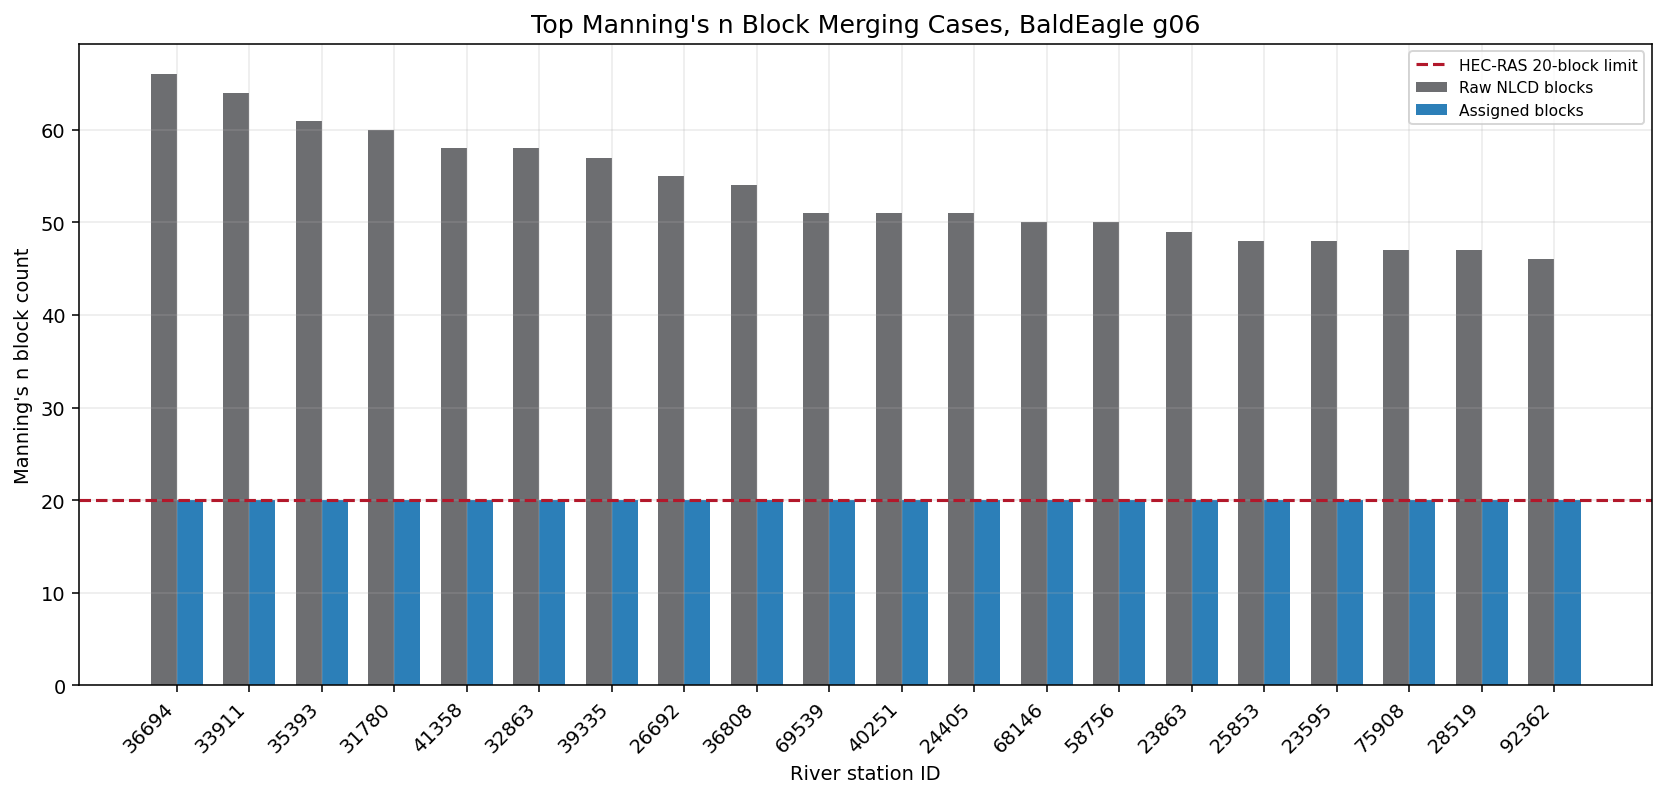

In [6]:
def area_weighted_summary(df: pd.DataFrame, label: str) -> pd.DataFrame:
    work = df.copy()
    work["weighted_n"] = work["n_value"].astype(float) * work["area_weight"].astype(float)
    summary = (
        work.groupby(["River", "Reach", "RS", "Subsection"], as_index=False)
        .agg(area=("area_weight", "sum"), weighted_n=("weighted_n", "sum"), block_count=("n_value", "size"))
    )
    summary[f"{label}_area_weighted_n"] = np.where(
        summary["area"] > 0,
        summary["weighted_n"] / summary["area"],
        np.nan,
    )
    return summary.drop(columns=["weighted_n"]).rename(
        columns={"area": f"{label}_area", "block_count": f"{label}_subsection_block_count"}
    )


raw_aw = area_weighted_summary(raw_preview, "raw")
final_aw = area_weighted_summary(automated_preview, "final")
merge_preservation = raw_aw.merge(
    final_aw,
    on=["River", "Reach", "RS", "Subsection"],
    how="inner",
)
merge_preservation["abs_delta_area_weighted_n"] = (
    merge_preservation["final_area_weighted_n"] - merge_preservation["raw_area_weighted_n"]
).abs()
merge_preservation = merge_preservation.merge(
    block_counts[["River", "Reach", "RS", "merge_triggered", "raw_block_count", "automated_block_count"]],
    on=["River", "Reach", "RS"],
    how="left",
)

merge_metrics = pd.DataFrame(
    [
        {"metric": "XS requiring block merging", "value": int(block_counts["merge_triggered"].sum())},
        {"metric": "Raw blocks removed by merging", "value": int(block_counts["block_reduction"].sum())},
        {
            "metric": "Median abs area-weighted n change where merged",
            "value": f"{merge_preservation.loc[merge_preservation['merge_triggered'], 'abs_delta_area_weighted_n'].median():.4f}",
        },
        {
            "metric": "Maximum abs area-weighted n change where merged",
            "value": f"{merge_preservation.loc[merge_preservation['merge_triggered'], 'abs_delta_area_weighted_n'].max():.4f}",
        },
    ]
)
display(merge_metrics)
display(
    merge_preservation.loc[merge_preservation["merge_triggered"]]
    .sort_values("abs_delta_area_weighted_n", ascending=False)
    [[
        "River",
        "Reach",
        "RS",
        "Subsection",
        "raw_block_count",
        "automated_block_count",
        "raw_area_weighted_n",
        "final_area_weighted_n",
        "abs_delta_area_weighted_n",
    ]]
    .head(12)
    .round(4)
)

top_merge = block_counts.head(20).copy()
top_merge["XS"] = top_merge["RS"].astype(str)

fig, ax = plt.subplots(figsize=(12, 5.8))
x = np.arange(len(top_merge))
ax.bar(x - 0.18, top_merge["raw_block_count"], width=0.36, color="#6d6e71", label="Raw NLCD blocks")
ax.bar(x + 0.18, top_merge["automated_block_count"], width=0.36, color="#2c7fb8", label="Assigned blocks")
ax.axhline(MAX_MANNING_BLOCKS, color="#b2182b", linewidth=1.6, linestyle="--", label="HEC-RAS 20-block limit")
ax.set_title("Top Manning's n Block Merging Cases, BaldEagle g06")
ax.set_xlabel("River station ID")
ax.set_ylabel("Manning's n block count")
ax.set_xticks(x)
ax.set_xticklabels(top_merge["XS"], rotation=45, ha="right")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

assert merge_preservation.loc[merge_preservation["merge_triggered"], "abs_delta_area_weighted_n"].max() < 0.025


## Station Scatter: Automated vs Existing Geometry

Each point is an assigned Manning breakpoint. Color identifies the HEC-RAS subsection at that station, and the 1:1 line shows where automated NLCD roughness equals the existing geometry roughness.


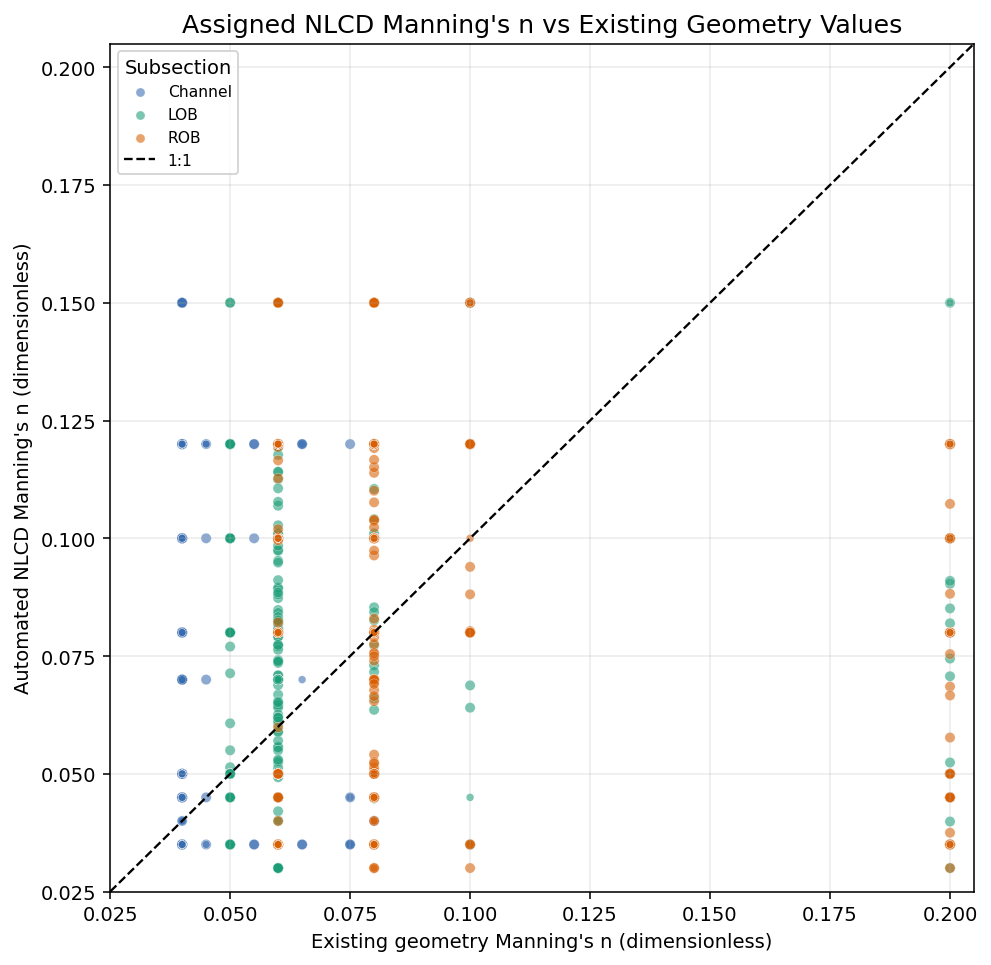

In [7]:
subsection_colors = {"LOB": "#1b9e77", "Channel": "#386cb0", "ROB": "#d95f02", "Unknown": "#7570b3"}

fig, ax = plt.subplots(figsize=(7.2, 7.0))
for subsection, group in station_comparison.groupby("Subsection"):
    ax.scatter(
        group["reference_n"],
        group["automated_n"],
        s=np.where(group["merge_triggered"], 28, 16),
        alpha=0.58,
        color=subsection_colors.get(subsection, "#7570b3"),
        edgecolor="white",
        linewidth=0.25,
        label=subsection,
    )
lims = [
    min(station_comparison["reference_n"].min(), station_comparison["automated_n"].min()) - 0.005,
    max(station_comparison["reference_n"].max(), station_comparison["automated_n"].max()) + 0.005,
]
ax.plot(lims, lims, color="black", linewidth=1.2, linestyle="--", label="1:1")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_title("Assigned NLCD Manning's n vs Existing Geometry Values")
ax.set_xlabel("Existing geometry Manning's n (dimensionless)")
ax.set_ylabel("Automated NLCD Manning's n (dimensionless)")
ax.legend(title="Subsection", loc="upper left")
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()


## Spatial Review Map

The map colors cross-section cut lines by the dominant NLCD class sampled along each section. Cross sections where the block limit was enforced are drawn with heavier black-edged linework.


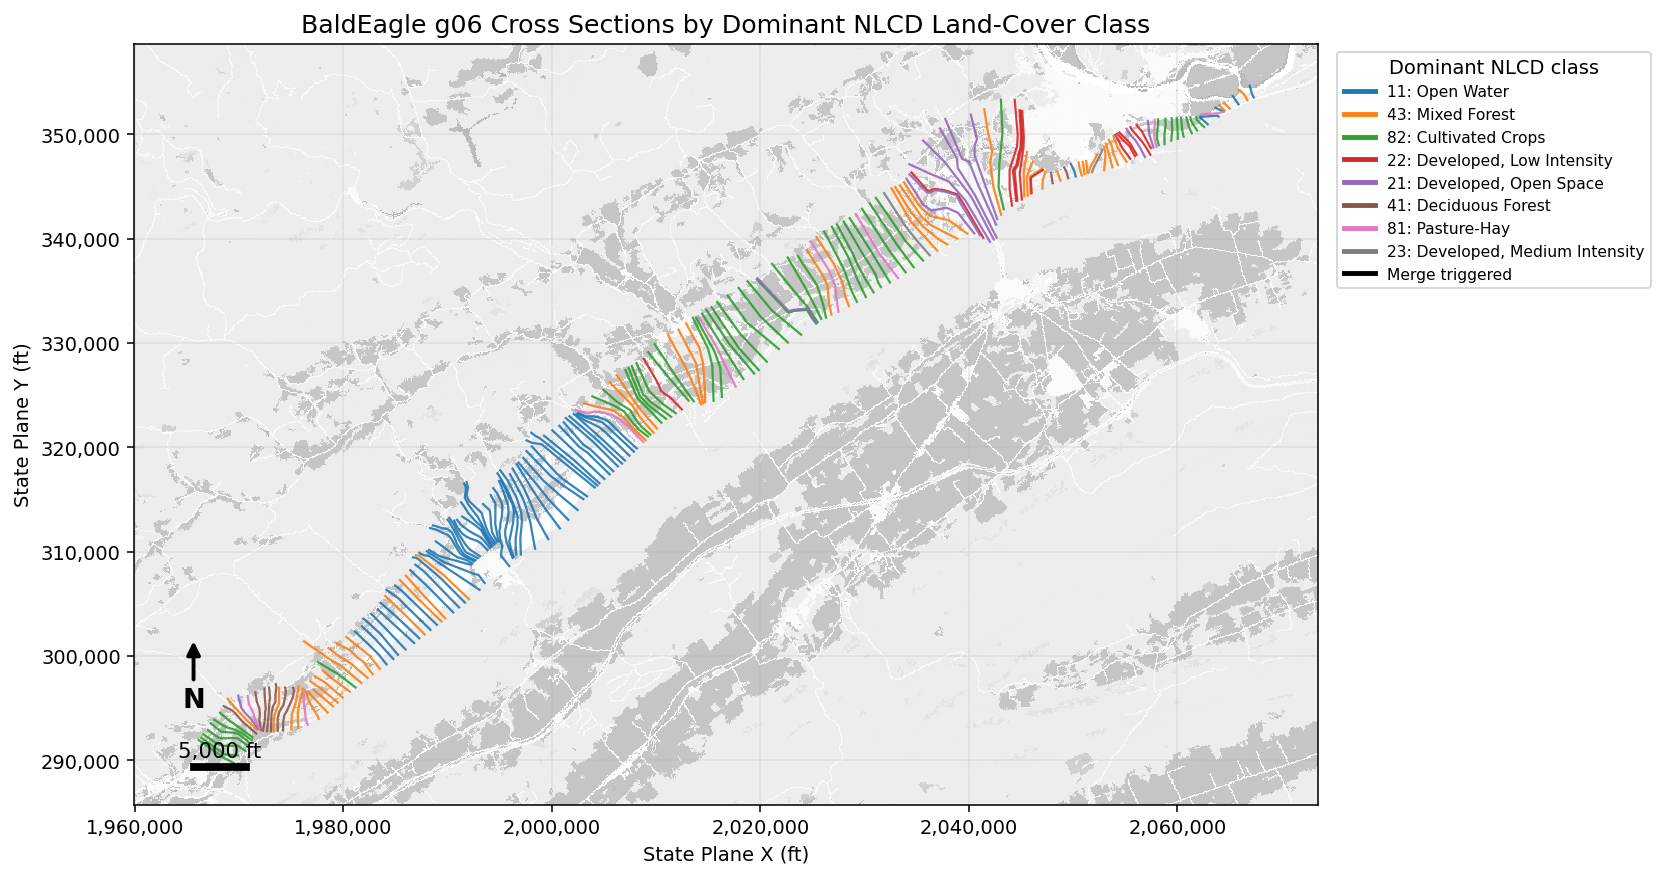

,dominant_class,cross_section_count
0,Open Water,57
1,Mixed Forest,47
2,Cultivated Crops,46
3,"Developed, Low Intensity",12
4,"Developed, Open Space",11
5,Deciduous Forest,9
6,Pasture-Hay,8
7,"Developed, Medium Intensity",2


In [8]:
dominant_rows = []
for _, row in raw_preview.iterrows():
    codes = [int(code) for code in str(row["nlcd_codes"]).split(",") if str(code).strip()]
    if not codes:
        continue
    share = float(row["area_weight"]) / len(codes)
    for code in codes:
        dominant_rows.append(
            {
                "River": row["River"],
                "Reach": row["Reach"],
                "RS": row["RS"],
                "nlcd_code": code,
                "area_weight": share,
            }
        )
dominant = (
    pd.DataFrame(dominant_rows)
    .groupby(["River", "Reach", "RS", "nlcd_code"], as_index=False)
    .agg(area_weight=("area_weight", "sum"))
    .sort_values(["River", "Reach", "RS", "area_weight"], ascending=[True, True, True, False])
    .drop_duplicates(["River", "Reach", "RS"])
)
dominant["class_name"] = dominant["nlcd_code"].map(lambda code: mapper_lookup.get(int(code), {}).get("class_name", str(code)))

xs_map = xs_rows[["River", "Reach", "RS", "geometry"]].merge(
    dominant[["River", "Reach", "RS", "nlcd_code", "class_name"]],
    on=["River", "Reach", "RS"],
    how="left",
).merge(
    block_counts[["River", "Reach", "RS", "merge_triggered"]],
    on=["River", "Reach", "RS"],
    how="left",
)
with rasterio.open(analysis_raster) as src:
    xs_gdf = gpd.GeoDataFrame(xs_map, geometry="geometry", crs=src.crs)
    minx, miny, maxx, maxy = xs_gdf.total_bounds
    pad_x = (maxx - minx) * 0.06
    pad_y = (maxy - miny) * 0.06
    bounds = (minx - pad_x, miny - pad_y, maxx + pad_x, maxy + pad_y)
    window = from_bounds(*bounds, transform=src.transform).round_offsets().round_lengths()
    landcover_subset = src.read(1, window=window, boundless=True, fill_value=src.nodata or 0)
    subset_transform = src.window_transform(window)
    extent = (
        subset_transform.c,
        subset_transform.c + subset_transform.a * landcover_subset.shape[1],
        subset_transform.f + subset_transform.e * landcover_subset.shape[0],
        subset_transform.f,
    )

top_map_codes = (
    xs_gdf["nlcd_code"].dropna().astype(int).value_counts().head(8).index.tolist()
)
line_palette = list(plt.cm.tab10.colors) + list(plt.cm.Set2.colors)
code_color = {code: line_palette[i % len(line_palette)] for i, code in enumerate(top_map_codes)}

fig, ax = plt.subplots(figsize=(12.0, 8.0))
masked = np.ma.masked_where(landcover_subset == (0 if src.nodata is None else src.nodata), landcover_subset)
ax.imshow(masked, extent=extent, origin="upper", cmap="Greys", alpha=0.28, interpolation="nearest")

for code in top_map_codes:
    subset = xs_gdf[xs_gdf["nlcd_code"].astype("Int64") == code]
    subset.plot(ax=ax, color=code_color[code], linewidth=1.15, alpha=0.9)

merged_subset = xs_gdf[xs_gdf["merge_triggered"].fillna(False)]
merged_subset.plot(ax=ax, color="none", edgecolor="black", linewidth=1.8, alpha=0.8)

ax.set_title("BaldEagle g06 Cross Sections by Dominant NLCD Land-Cover Class")
ax.set_xlabel("State Plane X (ft)")
ax.set_ylabel("State Plane Y (ft)")
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set_xlim(bounds[0], bounds[2])
ax.set_ylim(bounds[1], bounds[3])
ax.set_aspect("equal")

legend_handles = [
    Line2D([0], [0], color=code_color[code], lw=2.5, label=f"{code}: {mapper_lookup[code]['class_name']}")
    for code in top_map_codes
]
legend_handles.append(Line2D([0], [0], color="black", lw=2.5, label="Merge triggered"))
ax.legend(handles=legend_handles, title="Dominant NLCD class", loc="upper left", bbox_to_anchor=(1.01, 1.0))

# North arrow and 5,000 ft scale bar in project coordinates.
arrow_x = bounds[0] + 0.05 * (bounds[2] - bounds[0])
arrow_y = bounds[1] + 0.12 * (bounds[3] - bounds[1])
north_len = 0.10 * (bounds[3] - bounds[1])
ax.annotate(
    "N",
    xy=(arrow_x, arrow_y + north_len),
    xytext=(arrow_x, arrow_y),
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold",
    arrowprops={"arrowstyle": "-|>", "lw": 2.0, "color": "black"},
)
scale_x0 = bounds[0] + 0.05 * (bounds[2] - bounds[0])
scale_y = bounds[1] + 0.05 * (bounds[3] - bounds[1])
scale_len = 5000.0
ax.plot([scale_x0, scale_x0 + scale_len], [scale_y, scale_y], color="black", lw=4)
ax.text(scale_x0 + scale_len / 2, scale_y + 550, "5,000 ft", ha="center", va="bottom", fontsize=11)

fig.tight_layout()
plt.show()

display(
    xs_gdf["class_name"]
    .value_counts()
    .rename_axis("dominant_class")
    .reset_index(name="cross_section_count")
    .head(10)
)


## Findings

The automated assignment is intentionally more spatially detailed than the existing three-block geometry. Agreement with the RAS Mapper land-cover sidecar is exact at the raw NLCD block level, while differences from the existing geometry identify locations where NLCD classes recommend rougher or smoother overbank/channel values.


In [9]:
merged_preservation = merge_preservation.loc[merge_preservation["merge_triggered"]]
exact_existing = station_comparison["abs_delta_n"].le(0.001).mean() * 100.0
within_002 = station_comparison["abs_delta_n"].le(0.020).mean() * 100.0
mapper_agreement = raw_mapper_checks["matches_mapper"].mean() * 100.0
max_delta = station_comparison["abs_delta_n"].max()
max_preserve_delta = merged_preservation["abs_delta_area_weighted_n"].max()
median_preserve_delta = merged_preservation["abs_delta_area_weighted_n"].median()
most_common_dominant = xs_gdf["class_name"].value_counts().idxmax()

findings = f'''
### Validation Findings

- `ManningsFromLandCover.assign()` processed {assignment_result['cross_sections_processed']} real g06 cross sections and wrote {assignment_result['blocks_written']} Manning's n blocks to the copied geometry.
- The original geometry baseline has exactly 3 blocks per processed cross section; the automated assignment has {block_counts['automated_block_count'].mean():.1f} blocks per cross section on average and never exceeds the {MAX_MANNING_BLOCKS}-block limit.
- Block merging was triggered on {int(block_counts['merge_triggered'].sum())} of {len(block_counts)} processed cross sections. The largest raw count was {int(block_counts['raw_block_count'].max())} blocks.
- Raw NLCD block n-values matched the RAS Mapper sidecar `ManningsN` table for {mapper_agreement:.1f}% of checked class/block pairs.
- Compared with the existing 3-block geometry, {exact_existing:.1f}% of assigned station blocks match within 0.001 n and {within_002:.1f}% are within 0.020 n. The largest station-level absolute difference is {max_delta:.3f}.
- For merged cross sections, the median LOB/channel/ROB area-weighted n change is {median_preserve_delta:.4f}; the maximum is {max_preserve_delta:.4f}. This supports that merging is preserving subsection-scale hydraulic character while reducing noisy land-cover segmentation.
- The most common dominant sampled land-cover class is `{most_common_dominant}`.
'''
display(Markdown(findings))

assert mapper_agreement == 100.0
assert block_counts["automated_block_count"].max() == MAX_MANNING_BLOCKS
assert max_preserve_delta < 0.025



### Validation Findings

- `ManningsFromLandCover.assign()` processed 192 real g06 cross sections and wrote 3414 Manning's n blocks to the copied geometry.
- The original geometry baseline has exactly 3 blocks per processed cross section; the automated assignment has 17.8 blocks per cross section on average and never exceeds the 20-block limit.
- Block merging was triggered on 115 of 192 processed cross sections. The largest raw count was 66 blocks.
- Raw NLCD block n-values matched the RAS Mapper sidecar `ManningsN` table for 100.0% of checked class/block pairs.
- Compared with the existing 3-block geometry, 3.2% of assigned station blocks match within 0.001 n and 30.1% are within 0.020 n. The largest station-level absolute difference is 0.170.
- For merged cross sections, the median LOB/channel/ROB area-weighted n change is 0.0000; the maximum is 0.0000. This supports that merging is preserving subsection-scale hydraulic character while reducing noisy land-cover segmentation.
- The most common dominant sampled land-cover class is `Open Water`.
